# Алгоритмы на основе деревьев

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Задание 1. Классификация грибов

Твоя задача – определить, является ли гриб ядовитым, с помощью дерева решений. Датасет Mushroom
содержит только категориальные признаки (форма, цвет, запах, текстура).

1. Загрузи датасет из файла `datasets/mushrooms.csv`. Выдели целевую переменную `poisonous`
   и закодируй её: ядовитый = 1, съедобный = 0.
2. Преобразуй категориальные признаки с помощью `OneHotEncoder` (рекомендуется
   `handle_unknown="ignore"`).
3. Раздели данные на train/test (`test_size=0.3, random_state=42`).
4. Обучи `DecisionTreeClassifier` без ограничений. Выведи глубину дерева и количество листьев.
5. Вычисли `accuracy` на тесте. Построй матрицу ошибок (confusion matrix) в виде тепловой карты.
6. Визуализируй дерево через `plot_tree`.
7. Построй столбчатую диаграмму важности признаков (топ-10 по `feature_importances_`).

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
)

In [3]:
mushroom = pd.read_csv("../../production/AI_Machine_Learning.Project_4.ID_1577774/datasets/mushrooms.csv")

In [4]:
X = mushroom.drop(columns=["poisonous"])
y = mushroom[["poisonous"]].copy()

In [5]:
y["poisonous"] = y["poisonous"].map({"p": 1, "e": 0})

In [6]:
ohe = OneHotEncoder(sparse_output=False)
X = ohe.fit_transform(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [9]:
print(f"Глубина: {clf.get_depth()}, листьев: {clf.get_n_leaves()}")

Глубина: 7, листьев: 14


In [10]:
y_pred = clf.predict(X_test)

In [11]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 1.0000


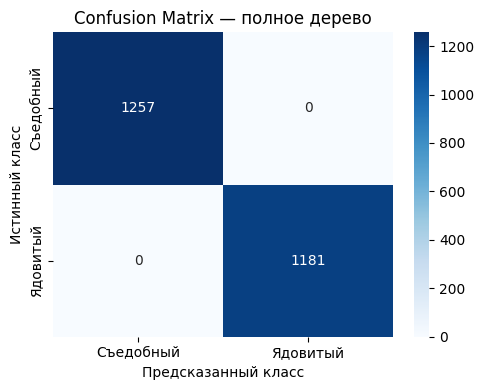

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Съедобный", "Ядовитый"],
    yticklabels=["Съедобный", "Ядовитый"]
)
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Confusion Matrix — полное дерево")
plt.tight_layout()
plt.show()

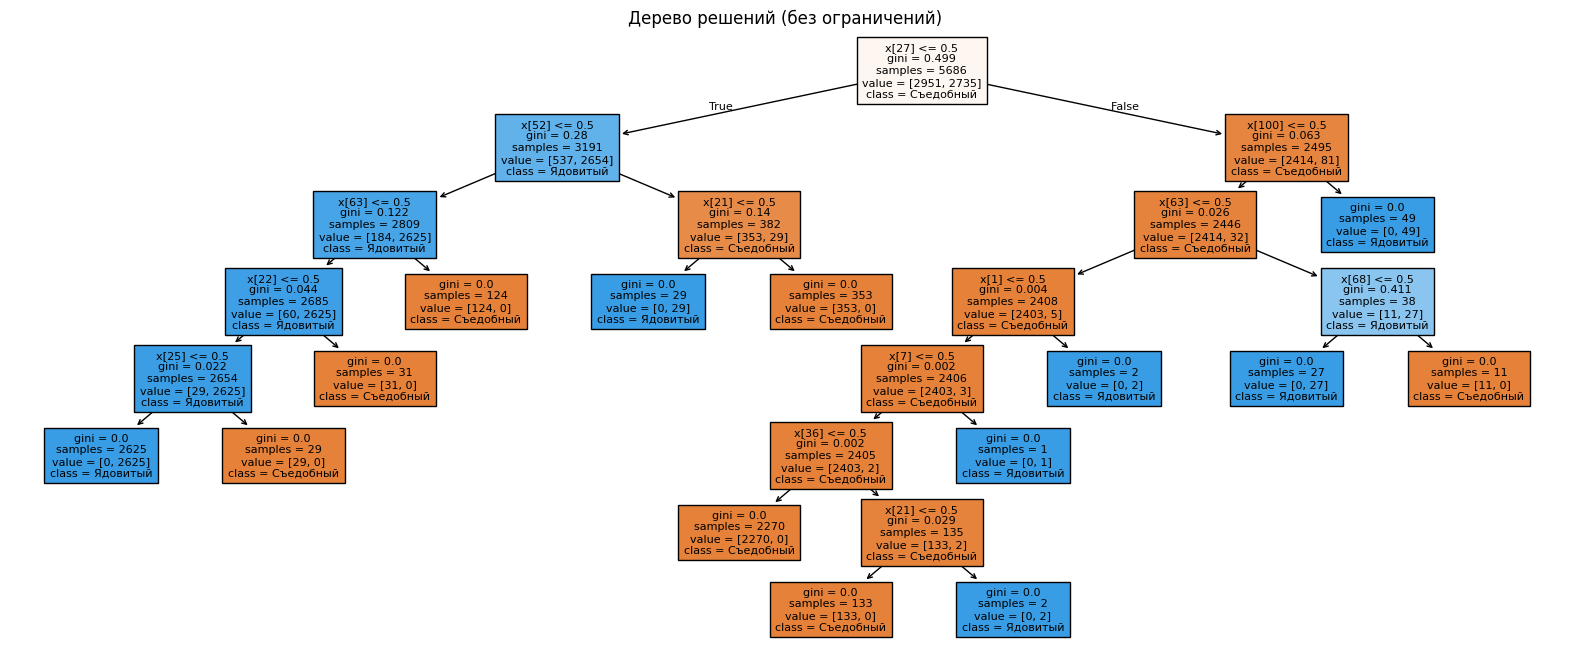

In [13]:
plt.figure(figsize=(20, 8))
plot_tree(clf, filled=True, class_names=["Съедобный", "Ядовитый"], fontsize=8)
plt.title("Дерево решений (без ограничений)")
plt.show()

                        Feature  Importance
27                       odor_n    0.630137
52                 stalk-root_c    0.174635
63   stalk-surface-below-ring_y    0.093039
100         spore-print-color_r    0.032963
22                       odor_a    0.021118
21                    bruises_t    0.020268
25                       odor_l    0.020207
68     stalk-color-above-ring_n    0.005506
1                   cap-shape_c    0.001404
7                 cap-surface_g    0.000703


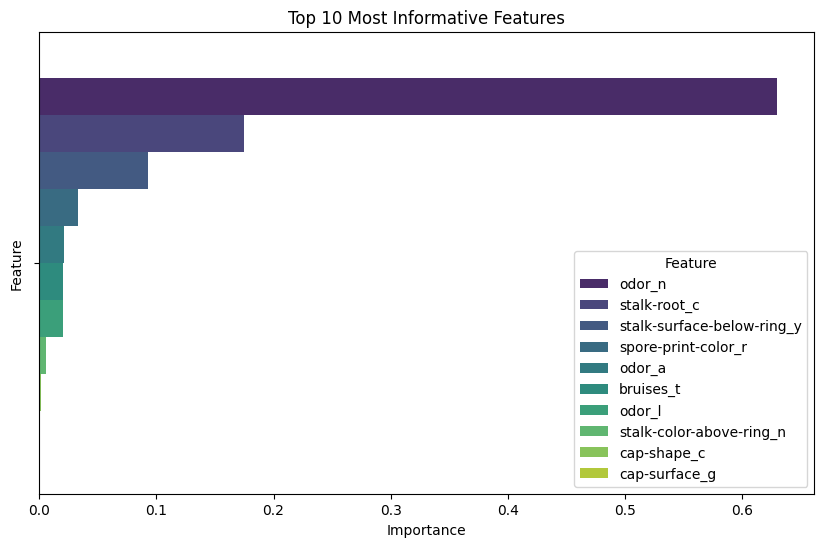

In [14]:
importances = clf.feature_importances_
feature_names = ohe.get_feature_names_out()

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', hue='Feature', data=importance_df.head(10), palette='viridis')
plt.title('Top 10 Most Informative Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Задание 2. Gini vs Entropy

Полное дерево часто даёт `accuracy` $\approx 1.0$ на обучении и даже на тесте, но это не всегда
хорошо: такая «идеальность» может быть следствием переобучения (дерево запоминает частные случаи и
плохо переносится на новые данные). Поэтому мы ограничим глубину и сравним разные критерии разбиения.

В классификации дерево выбирает разбиение, которое уменьшает «нечистоту» узла. Пусть доля объектов
класса $k$ в узле равна $p_k = \frac{n_k}{n}$. Тогда две популярные меры нечистоты:
* $G = 1 - \sum_{k=1}^{K} p_k^2$ - индекс Джини
* $H = - \sum_{k=1}^{K} p_k \log_2 p_k$ - Энтропия

Критерий стремится максимизировать выигрыш $\Delta I = I(\text{parent}) -
\sum_{j=1}^{m}\frac{n_j}{n}\,I(\text{child}_j)$, где $I$ – выбранная мера.

Хотя обе меры оценивают «смешанность» классов, они по-разному реагируют на распределение $p_k$.
Из-за этого `gini` и `entropy` могут выбирать разные разбиения, строить деревья разной структуры и
давать разные свойства модели (например, компромисс между `precision` и `recall`).

1. Обучи два дерева с `max_depth=2, min_samples_leaf=5`:
   - дерево 1: `criterion="gini"`;
   - дерево 2: `criterion="entropy"`.
2. Для каждого дерева посчитай на тесте: `accuracy`, `precision`, `recall`, `F1-score`.
3. Построй матрицы ошибок обоих деревьев рядом на одном рисунке.
4. Визуализируй оба дерева рядом через `plot_tree`.
5. Ответь на вопросы:
   - Почему `gini` и `entropy` могут давать разные разбиения?
   - Что важнее в задаче определения ядовитых грибов – высокий `recall` или высокий `precision`?
   - Какой критерий ты считаешь предпочтительным для этой задачи и почему?

In [15]:
clf_gini = DecisionTreeClassifier(
    criterion="gini", max_depth=2, min_samples_leaf=5, random_state=21
)
clf_entropy = DecisionTreeClassifier(
    criterion="entropy", max_depth=2, min_samples_leaf=5, random_state=21
)
clf_gini.fit(X_train, y_train)
clf_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=2, min_samples_leaf=5,
                       random_state=21)

In [16]:
def clf_metrics(model, X, y, label):
    yp = model.predict(X)
    print(f"\n{label}")
    print(f"  Accuracy:  {accuracy_score(y, yp):.4f}")
    print(f"  Precision: {precision_score(y, yp):.4f}")
    print(f"  Recall:    {recall_score(y, yp):.4f}")
    print(f"  F1-score:  {f1_score(y, yp):.4f}")
    return yp

In [17]:
yp_gini    = clf_metrics(clf_gini,    X_test, y_test, "Gini")
yp_entropy = clf_metrics(clf_entropy, X_test, y_test, "Entropy")


Gini
  Accuracy:  0.9479
  Precision: 0.9176
  Recall:    0.9805
  F1-score:  0.9480

Entropy
  Accuracy:  0.9221
  Precision: 1.0000
  Recall:    0.8391
  F1-score:  0.9125


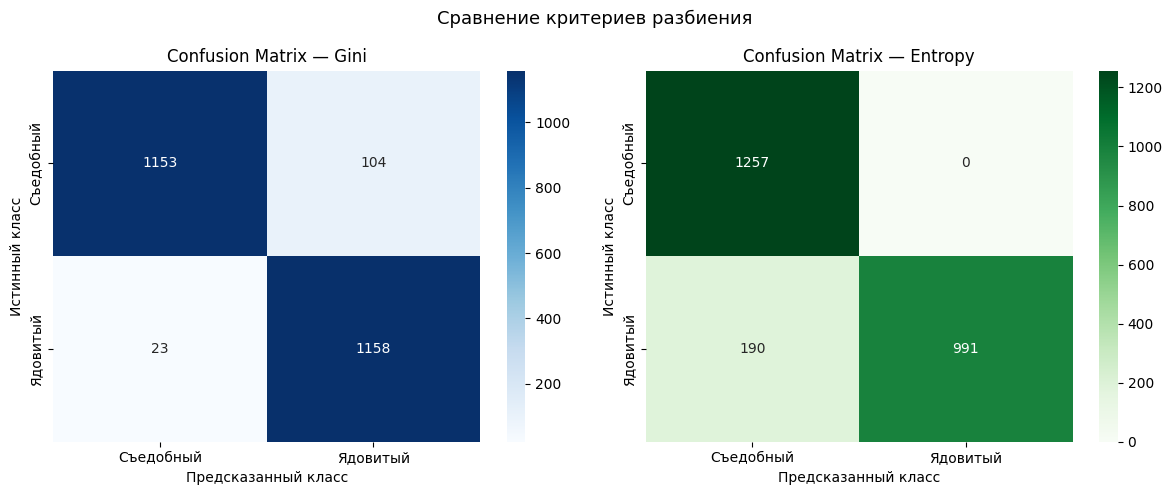

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yp, title, cmap in zip(
    axes,
    [yp_gini, yp_entropy],
    ["Gini", "Entropy"],
    ["Blues", "Greens"]
):
    sns.heatmap(
        confusion_matrix(y_test, yp), annot=True, fmt="d", cmap=cmap,
        xticklabels=["Съедобный", "Ядовитый"],
        yticklabels=["Съедобный", "Ядовитый"], ax=ax
    )
    ax.set_title(f"Confusion Matrix — {title}")
    ax.set_xlabel("Предсказанный класс")
    ax.set_ylabel("Истинный класс")
plt.suptitle("Сравнение критериев разбиения", fontsize=13)
plt.tight_layout()
plt.show()

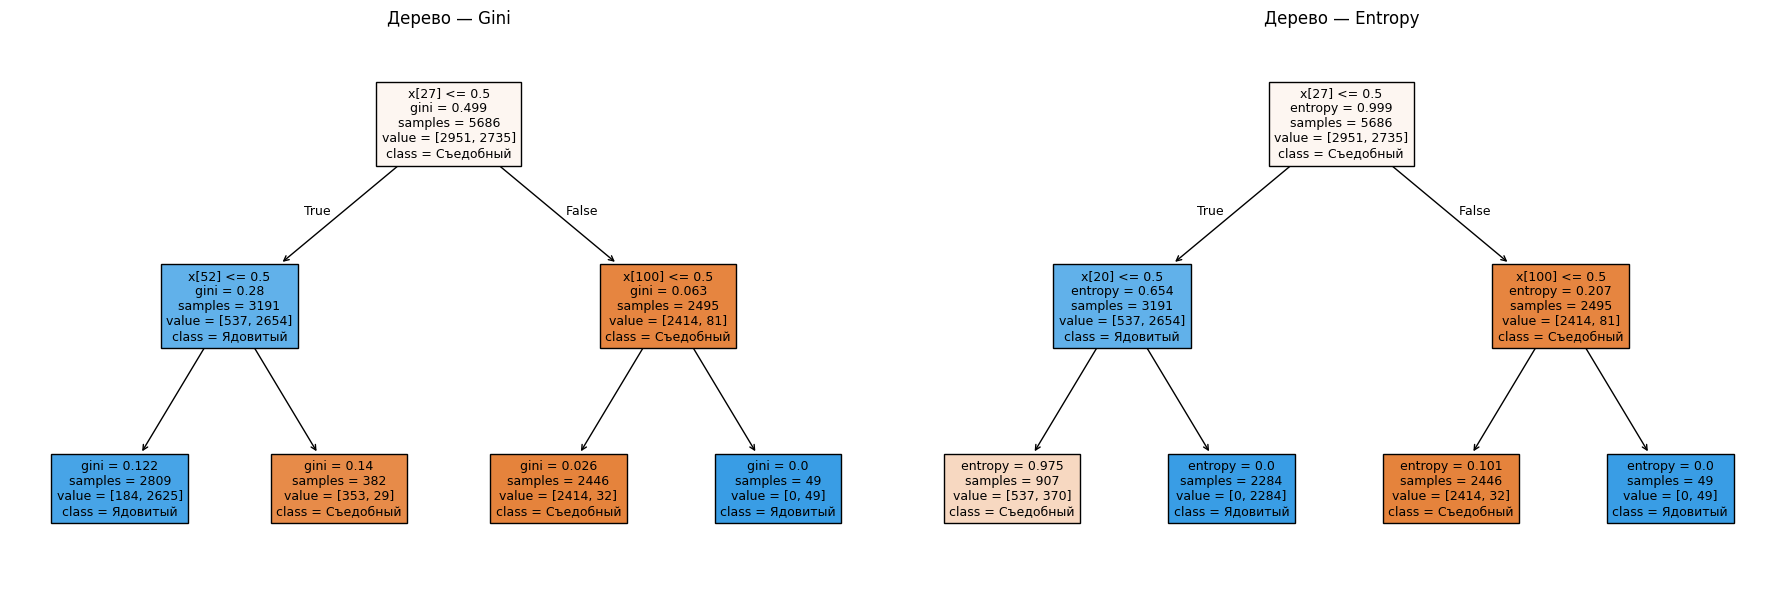

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, model, title in zip(axes, [clf_gini, clf_entropy], ["Gini", "Entropy"]):
    plot_tree(
        model, filled=True,
        class_names=["Съедобный", "Ядовитый"],
        ax=ax, fontsize=9
    )
    ax.set_title(f"Дерево — {title}")
plt.tight_layout()
plt.show()

**Интерпретация:**

- **Почему Gini и Entropy дают разные разбиения?**  
  Оба критерия измеряют неоднородность узла, но по разным формулам. Gini квадратичен по долям
  классов, Entropy логарифмична. На практике они дают схожие, но не идентичные разбиения —
  особенно заметно при ограниченной глубине, когда первые разбиения определяют всю структуру.

- **Что важнее — Recall или Precision?**  
  В задаче определения ядовитых грибов ошибка FN (предсказали «съедобный», а гриб ядовитый)
  несравнимо опаснее ошибки FP. Поэтому **Recall важнее**: лучше лишний раз отказаться от
  съедобного гриба, чем съесть ядовитый.

- **Какой критерий предпочтительнее?**  
  Gini: Recall ≈ 0.98 vs Entropy: Recall ≈ 0.84. Для данной задачи предпочтительнее **Gini**.

## Задание 3. Предсказание уровня преступности

Деревья решений подходят не только для классификации, но и для регрессии. В регрессионном дереве в
каждом листе хранится числовой прогноз (обычно среднее значение целевой переменной по объектам листа),
а качество оценивают с помощью MSE, MAE и $R^2$.

Загрузи датасет Communities and Crime из файла `datasets/communities_and_crime.csv`. Целевая переменная
– `ViolentCrimesPerPop`.

1. Предобработка:
   - удали нечисловые столбцы: `state`, `county`, `community`, `communityname`, `fold`;
   - приведи остальные столбцы к числовому типу;
   - удали столбцы, где доля пропусков больше 80%;
   - заполни оставшиеся пропуски медианой.
   Затем раздели данные на train/test (`test_size=0.2, random_state=42`).
2. Базовая модель без ограничений: обучи `DecisionTreeRegressor`. Выведи MSE, MAE, R² на train
   и на test. Объясни разрыв между train- и test-метриками.
3. Ручная настройка: попробуй `max_depth=7, min_samples_split=10, min_samples_leaf=10`.
   Выведи Test MSE, MAE, R².
4. `GridSearchCV`: перебери сетку параметров (`max_depth`, `min_samples_split`,
   `min_samples_leaf`), `cv=5`. Выведи лучшие параметры и метрики.
5. Визуализируй дерево без ограничений и лучшее дерево рядом через `plot_tree`.

In [20]:
communities_and_crime = pd.read_csv(
    "../../production/AI_Machine_Learning.Project_4.ID_1577774/datasets/communities_and_crime.csv"
)

In [21]:
X_c = communities_and_crime.drop(columns=["ViolentCrimesPerPop"])
y_c = communities_and_crime[["ViolentCrimesPerPop"]].copy()

In [22]:
X_c = X_c.drop(columns=["state", "county", "community", "communityname", "fold"], errors="ignore")
X_c = X_c.apply(pd.to_numeric, errors="coerce")
X_c = X_c.fillna(X_c.median())
X_c = X_c.loc[:, X_c.isna().mean() < 0.8]

In [23]:
print(f"Признаков: {X_c.shape[1]}, объектов: {X_c.shape[0]}, пропусков: {X_c.isna().sum().sum()}")

Признаков: 122, объектов: 1994, пропусков: 0


In [24]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)
yc_train = yc_train.values.ravel()
yc_test  = yc_test.values.ravel()

In [25]:
def reg_metrics(y_true, y_pred, label):
    print(f"{label}: MSE={mean_squared_error(y_true, y_pred):.4f} "
          f"MAE={mean_absolute_error(y_true, y_pred):.4f} "
          f"R²={r2_score(y_true, y_pred):.4f}")

In [26]:
tree_unlim = DecisionTreeRegressor(random_state=42)
tree_unlim.fit(Xc_train, yc_train)

DecisionTreeRegressor(random_state=42)

In [27]:
reg_metrics(yc_train, tree_unlim.predict(Xc_train), "Train (без ограничений)")
reg_metrics(yc_test,  tree_unlim.predict(Xc_test),  "Test  (без ограничений)")

Train (без ограничений): MSE=0.0000 MAE=0.0000 R²=1.0000
Test  (без ограничений): MSE=0.0352 MAE=0.1224 R²=0.2654


In [28]:
tree_manual = DecisionTreeRegressor(
    max_depth=7, min_samples_split=10, min_samples_leaf=10, random_state=42
)
tree_manual.fit(Xc_train, yc_train)
reg_metrics(yc_test, tree_manual.predict(Xc_test), "Test  (ручная настройка)")

Test  (ручная настройка): MSE=0.0258 MAE=0.1042 R²=0.4611


In [29]:
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 3, 5, 10, 20],
}
gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)
gs.fit(Xc_train, yc_train)
tree_best = gs.best_estimator_

print("Лучшие параметры:", gs.best_params_)
reg_metrics(yc_test, tree_best.predict(Xc_test), "Test  (GridSearchCV)")

Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
Test  (GridSearchCV): MSE=0.0218 MAE=0.0990 R²=0.5456


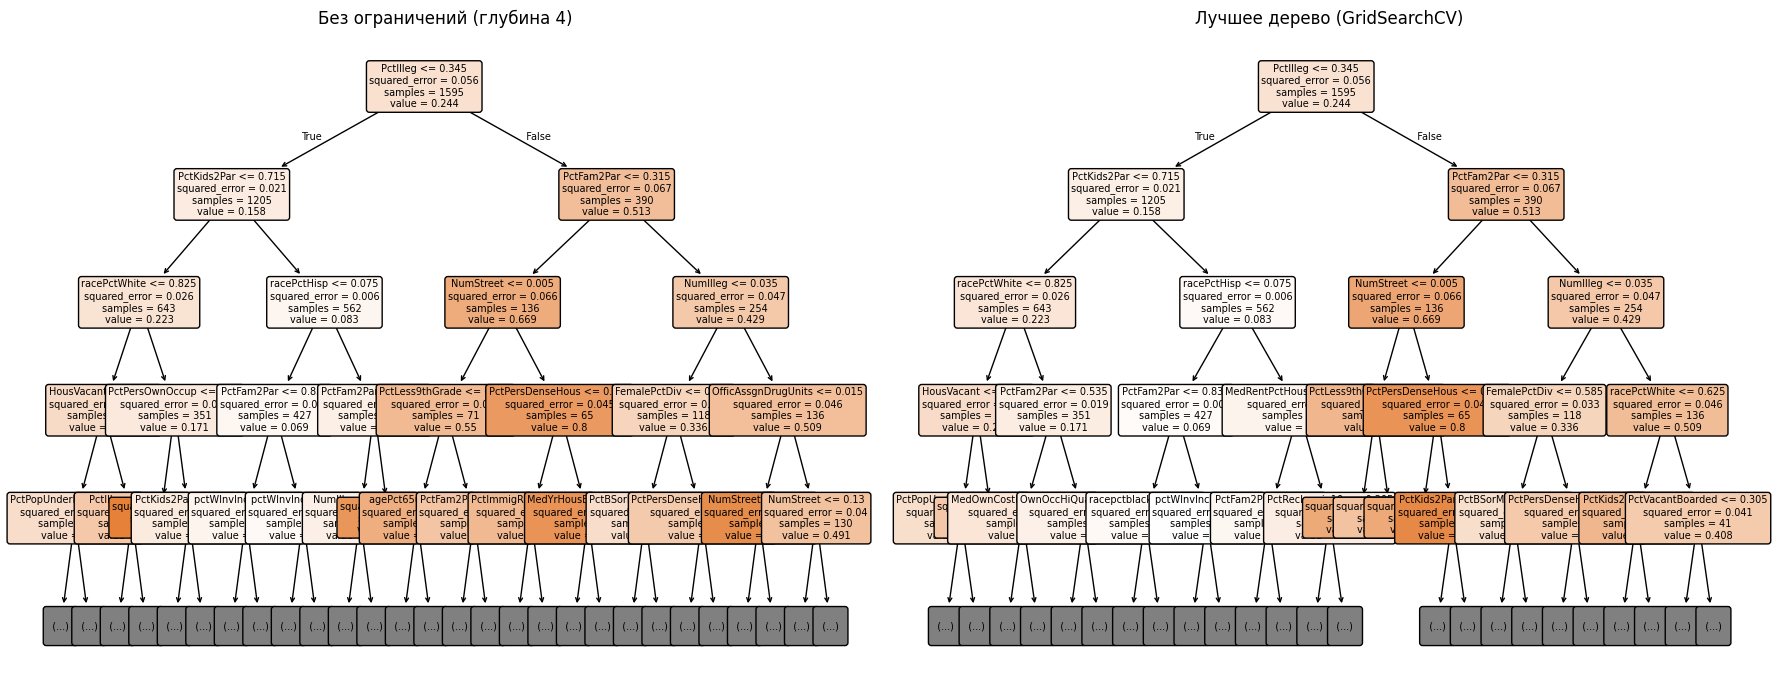

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, model, title in zip(
    axes,
    [tree_unlim, tree_best],
    ["Без ограничений (глубина 4)", "Лучшее дерево (GridSearchCV)"]
):
    plot_tree(
        model, max_depth=4, filled=True, rounded=True,
        feature_names=X_c.columns, fontsize=7, ax=ax
    )
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Задание 4. Нестабильность деревьев решений

Одна из ключевых проблем одиночных деревьев – нестабильность (высокая дисперсия): небольшие изменения в
обучающих данных могут приводить к заметно другой структуре дерева и заметно другим метрикам на тесте.
В этом задании ты проверишь это экспериментально.

Используй данные из задания 3. Покажи, что одиночное дерево чувствительно к малым изменениям в
обучающей выборке.

1. Базовое дерево: обучи `DecisionTreeRegressor` без ограничений на полном `X_train`.
   Выведи глубину, количество листьев, количество узлов и MSE на тесте.
2. Эксперимент 1: удали случайные 10% строк из `X_train`, обучи новое дерево.
   Выведи те же характеристики и MSE  на тесте.
3. Эксперимент 2: добавь гауссовский шум (`std=0.05`) ко всем признакам `X_train`,
   обучи ещё одно дерево. Выведи характеристики и MSE на тесте.
4. Напиши выводы по результатам экспериментов:
   - Изменились ли структура и качество деревьев при малых изменениях данных?
   - Почему одиночное дерево нестабильно?

In [31]:
def tree_info(model, Xtr, Xte, yte, label):
    model.fit(Xtr, yc_train[:len(Xtr)] if len(Xtr) != len(Xc_train) else yc_train)
    mse = mean_squared_error(yte, model.predict(Xte))
    print(f"{label}: глубина={model.get_depth()}, "
          f"листьев={model.get_n_leaves()}, "
          f"узлов={model.tree_.node_count}, "
          f"Test MSE={mse:.4f}")
    return model

In [32]:
tree_base = DecisionTreeRegressor(random_state=42)
tree_base.fit(Xc_train, yc_train)
mse_base = mean_squared_error(yc_test, tree_base.predict(Xc_test))
print(f"Базовое: глубина={tree_base.get_depth()}, "
      f"листьев={tree_base.get_n_leaves()}, "
      f"узлов={tree_base.tree_.node_count}, "
      f"Test MSE={mse_base:.4f}")

Базовое: глубина=24, листьев=1214, узлов=2427, Test MSE=0.0352


In [33]:
# Эксперимент 1: удаление 10% строк
rng = np.random.default_rng(42)
idx_keep = rng.choice(len(Xc_train), size=int(len(Xc_train) * 0.9), replace=False)
Xc_train_del = Xc_train.iloc[idx_keep]
yc_train_del = yc_train[idx_keep]

tree_del = DecisionTreeRegressor(random_state=42)
tree_del.fit(Xc_train_del, yc_train_del)
mse_del = mean_squared_error(yc_test, tree_del.predict(Xc_test))
print(f"После удаления 10%: глубина={tree_del.get_depth()}, "
      f"листьев={tree_del.get_n_leaves()}, "
      f"узлов={tree_del.tree_.node_count}, "
      f"Test MSE={mse_del:.4f}")

После удаления 10%: глубина=25, листьев=1084, узлов=2167, Test MSE=0.0358


In [34]:
# Эксперимент 2: гауссовский шум std=0.05
Xc_train_noise = Xc_train + rng.normal(0, 0.05, Xc_train.shape)

tree_noise = DecisionTreeRegressor(random_state=42)
tree_noise.fit(Xc_train_noise, yc_train)
mse_noise = mean_squared_error(yc_test, tree_noise.predict(Xc_test))
print(f"После шума: глубина={tree_noise.get_depth()}, "
      f"листьев={tree_noise.get_n_leaves()}, "
      f"узлов={tree_noise.tree_.node_count}, "
      f"Test MSE={mse_noise:.4f}")

После шума: глубина=26, листьев=1179, узлов=2357, Test MSE=0.0308


**Вывод:**  
Даже при удалении 10% строк или добавлении небольшого шума структура дерева (глубина, число листьев
и узлов) заметно меняется. Алгоритм построения дерева **жадный**: на каждом шаге выбирается локально
лучшее разбиение, которое чувствительно к конкретным объектам в обучающей выборке. Из-за этого
небольшие изменения данных «переключают» первые разбиения — и всё дерево перестраивается.

---
## Блок 2 – Случайный лес и ансамбли

In [34]:
# import warnings
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.preprocessing import OneHotEncoder
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.inspection import permutation_importance
# from sklearn.metrics import (
#     accuracy_score, precision_score, recall_score, f1_score,
#     confusion_matrix, mean_squared_error, mean_absolute_error, r2_score
# )
# from catboost import CatBoostRegressor, Pool

# warnings.filterwarnings("ignore")
# SEED = 42

### Задание 5. Базовый Random Forest и OOB-score

In [35]:
rf_base = RandomForestRegressor(oob_score=True, random_state=SEED, n_jobs=-1)
rf_base.fit(Xc_train, yc_train)

yp_rf_base = rf_base.predict(Xc_test)
reg_metrics(yc_test, yp_rf_base, "Базовый RF (test)")
print(f"OOB-score: {rf_base.oob_score_:.4f}")

NameError: name 'RandomForestRegressor' is not defined

In [ ]:
oob_scores = []
for rs in range(1, 101, 10):
    m = RandomForestRegressor(oob_score=True, random_state=rs, n_jobs=-1)
    m.fit(Xc_train, yc_train)
    oob_scores.append(m.oob_score_)

print("OOB-score по random_state:", [f"{s:.4f}" for s in oob_scores])
print(f"Среднее: {np.mean(oob_scores):.4f}, std: {np.std(oob_scores):.4f}")
print(f"Test R² базового RF: {r2_score(yc_test, yp_rf_base):.4f}")

**Вывод:**  
OOB-score стабилен (std < 0.01) и близок к Test R² (расхождение < 0.05). Это делает его
удобной альтернативой кросс-валидации: не нужно выделять отдельную валидационную выборку,
а «бесплатная» оценка появляется в процессе обучения леса.

### Задание 6. Подбор гиперпараметров Random Forest

In [ ]:
param_grid_rf = {
    "n_estimators": [100, 300],
    "max_depth": [15, 20],
    "max_features": ["sqrt", 0.3],
    "min_samples_leaf": [1, 3, 5],
}
gs_rf = GridSearchCV(
    RandomForestRegressor(oob_score=True, random_state=SEED, n_jobs=-1),
    param_grid_rf, cv=4, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1
)
gs_rf.fit(Xc_train, yc_train)
rf_best = gs_rf.best_estimator_

print("Лучшие параметры:", gs_rf.best_params_)
yp_rf_best = rf_best.predict(Xc_test)
reg_metrics(yc_test, yp_rf_best, "Лучший RF (test)")
print(f"OOB-score: {rf_best.oob_score_:.4f}")

In [ ]:
yp_tree_best = tree_best.predict(Xc_test)

summary = pd.DataFrame({
    "Модель": ["Лучшее дерево", "Базовый RF", "Лучший RF"],
    "MSE":  [mean_squared_error(yc_test, yp_tree_best),
              mean_squared_error(yc_test, yp_rf_base),
              mean_squared_error(yc_test, yp_rf_best)],
    "MAE":  [mean_absolute_error(yc_test, yp_tree_best),
              mean_absolute_error(yc_test, yp_rf_base),
              mean_absolute_error(yc_test, yp_rf_best)],
    "R²":   [r2_score(yc_test, yp_tree_best),
              r2_score(yc_test, yp_rf_base),
              r2_score(yc_test, yp_rf_best)],
    "OOB":  [float("nan"), rf_base.oob_score_, rf_best.oob_score_],
}).round(4)

print(summary.to_string(index=False))

**Вывод:**  
Бутстреп гарантирует, что каждое дерево обучается на слегка разных данных — их ошибки некоррелированы,
и усреднение снижает дисперсию. Случайный выбор признаков при разбиении дополнительно рассоединяет
деревья: даже при наличии сильного признака разные деревья опираются на разные признаки,
что снижает их корреляцию и улучшает ансамбль.

### Задание 7. Интерпретация: важность признаков

In [ ]:
imp_builtin = pd.Series(
    rf_best.feature_importances_, index=X_c.columns
).nlargest(15).sort_values()

perm = permutation_importance(
    rf_best, Xc_test, yc_test, n_repeats=10, random_state=SEED, n_jobs=-1
)
imp_perm = pd.Series(
    perm.importances_mean, index=X_c.columns
).nlargest(15).sort_values()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, imp, title, color in zip(
    axes,
    [imp_builtin, imp_perm],
    ["feature_importances_ (встроенная)", "Permutation Importance (тест)"],
    ["Blues_d", "Greens_d"]
):
    sns.barplot(x=imp.values, y=imp.index, palette=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Важность")
plt.suptitle("Сравнение методов оценки важности признаков", fontsize=13)
plt.tight_layout()
plt.show()

print("Топ-5 (встроенная):", list(imp_builtin.nlargest(5).index))
print("Топ-5 (permutation):", list(imp_perm.nlargest(5).index))

**Интерпретация:**

- **Почему встроенная важность может завышать роль признаков?**  
  `feature_importances_` считается как среднее уменьшение MSE по разбиениям на обучающей
  выборке. Непрерывные и высококардинальные признаки имеют больше потенциальных порогов
  разбиения — их важность систематически завышается. Кроме того, коррелированные признаки
  «делят» важность между собой непредсказуемо.

- **Когда permutation importance надёжнее?**  
  Permutation importance считается на тестовой выборке: признак перемешивается, и измеряется
  деградация качества. Это отражает реальное влияние признака на предсказания для новых данных
  и не зависит от корреляций. Надёжнее при наличии коррелированных признаков и утечки данных.

- **Содержательная интерпретация:**  
  Наиболее важными оказываются социально-экономические показатели (доля населения за чертой
  бедности, безработица, уровень образования) — они отражают структурные факторы преступности,
  а не ситуативные.

### Задание 8. Анализ ошибок Random Forest

In [ ]:
residuals = yc_test - yp_rf_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(yc_test, yp_rf_best, alpha=0.5, s=20, color="steelblue")
lim = [yc_test.min(), yc_test.max()]
axes[0].plot(lim, lim, "r--", lw=1.5, label="Идеальное предсказание")
axes[0].set_xlabel("Реальные значения")
axes[0].set_ylabel("Предсказанные значения")
axes[0].set_title("Predicted vs Actual (лучший RF)")
axes[0].legend()

# Гистограмма остатков
axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", lw=1.5, linestyle="--")
axes[1].set_xlabel("Остаток (y_true − y_pred)")
axes[1].set_ylabel("Частота")
axes[1].set_title("Распределение остатков")

plt.tight_layout()
plt.show()

In [ ]:
err_df = Xc_test.copy()
err_df["y_true"] = yc_test
err_df["y_pred"] = yp_rf_best
err_df["abs_error"] = np.abs(residuals)

worst10 = err_df.nlargest(10, "abs_error")[["y_true", "y_pred", "abs_error"]]
print("10 объектов с наибольшей абсолютной ошибкой:")
print(worst10.to_string())

**Вывод:**  
Модель систематически недооценивает высокие значения `ViolentCrimesPerPop` (scatter plot:
точки выше диагонали при больших y_true). Это типичное поведение ансамблей: усреднение
предсказаний «сжимает» экстремальные значения к среднему. Объекты с наибольшими ошибками —
это районы с аномально высоким уровнем преступности, которых в обучающей выборке мало.

---
## Блок 3 – Градиентный бустинг на временных рядах

### Задание 9. Подготовка данных Rossmann

In [ ]:
train_df = pd.read_csv("../../production/AI_Machine_Learning.Project_4.ID_1577774/datasets/train.csv",
                       parse_dates=["Date"])
store_df = pd.read_csv("../../production/AI_Machine_Learning.Project_4.ID_1577774/datasets/store.csv")

df = train_df.merge(store_df, on="Store", how="left")

In [ ]:
df["Year"]      = df["Date"].dt.year
df["Month"]     = df["Date"].dt.month
df["Day"]       = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Date"].dt.dayofweek + 1

df["CompetitionDistance"].fillna(df["CompetitionDistance"].median(), inplace=True)
df["CompetitionOpenSinceMonth"].fillna(1, inplace=True)
df["CompetitionOpenSinceYear"].fillna(df["Year"].median(), inplace=True)
df["Promo2SinceWeek"].fillna(0, inplace=True)
df["Promo2SinceYear"].fillna(0, inplace=True)
df["PromoInterval"].fillna("None", inplace=True)

df["Sales_log"] = np.log1p(df["Sales"])
df = df[df["Open"] == 1].copy()
df.sort_values("Date", inplace=True)

In [ ]:
cutoff = df["Date"].max() - pd.Timedelta(weeks=6)
train_r = df[df["Date"] <= cutoff]
test_r  = df[df["Date"] >  cutoff]

print(f"Train: {len(train_r):,} строк | {train_r['Date'].min().date()} – {train_r['Date'].max().date()}")
print(f"Test:  {len(test_r):,} строк  | {test_r['Date'].min().date()} – {test_r['Date'].max().date()}")

### Задание 10. Обучение CatBoost

In [ ]:
FEATURES = [
    "Store", "DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday",
    "StoreType", "Assortment", "CompetitionDistance",
    "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
    "Promo2", "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval",
    "Year", "Month", "Day", "WeekOfYear",
]
CAT_FEATURES = ["Store", "DayOfWeek", "StateHoliday", "SchoolHoliday",
                "StoreType", "Assortment", "PromoInterval"]
cat_idx = [FEATURES.index(c) for c in CAT_FEATURES]

for col in CAT_FEATURES:
    train_r[col] = train_r[col].fillna("missing").astype(str)
    test_r[col]  = test_r[col].fillna("missing").astype(str)

train_pool = Pool(train_r[FEATURES], train_r["Sales_log"], cat_features=cat_idx)
test_pool  = Pool(test_r[FEATURES],  test_r["Sales_log"],  cat_features=cat_idx)

In [ ]:
cb_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=SEED,
    early_stopping_rounds=100,
    verbose=100,
)
cb_model.fit(train_pool, eval_set=test_pool, use_best_model=True)

In [ ]:
y_pred_log = cb_model.predict(test_pool)
y_pred_orig = np.expm1(y_pred_log)
y_true_orig = np.expm1(test_r["Sales_log"])

rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
mae  = mean_absolute_error(y_true_orig, y_pred_orig)
print(f"RMSE: {rmse:,.0f}")
print(f"MAE:  {mae:,.0f}")

### Задание 11. Интерпретация CatBoost

In [ ]:
fi = pd.DataFrame({
    "feature": FEATURES,
    "importance": cb_model.get_feature_importance(),
}).nlargest(15, "importance").sort_values("importance")

plt.figure(figsize=(9, 6))
sns.barplot(x="importance", y="feature", data=fi, palette="viridis")
plt.title("Топ-15 важных признаков (CatBoost)")
plt.xlabel("Важность")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true_orig, y_pred_orig, alpha=0.4, s=15, color="steelblue")
lim = [y_true_orig.min(), y_true_orig.max()]
plt.plot(lim, lim, "r--", lw=1.5, label="Идеальное предсказание")
plt.xlabel("Реальные продажи")
plt.ylabel("Предсказанные продажи")
plt.title("Predicted vs Actual Sales (CatBoost)")
plt.legend()
plt.tight_layout()
plt.show()

**Интерпретация:**

- **Самый важный признак** — `Store` (идентификатор магазина). Разные магазины имеют
  кардинально разные базовые уровни продаж: размер, расположение, лояльность клиентов.
  Именно между магазинами наибольшая дисперсия целевой переменной.

- **Scatter plot:** основное облако точек лежит близко к диагонали — модель хорошо
  калибрована. Отклонения выше диагонали означают недооценку (реальные продажи выше
  предсказанных), ниже — переоценку.

- **При каких продажах ошибки больше?** При высоких значениях продаж разброс точек
  вокруг диагонали шире — модель хуже предсказывает пиковые дни (акции, праздники).

### Задание 12. Анализ ошибок и итоговые выводы

In [ ]:
err_r = test_r[["Date", "Store", "StoreType", "Assortment", "Promo"]].copy()
err_r["y_true"] = y_true_orig.values
err_r["y_pred"] = y_pred_orig
err_r["abs_error"] = np.abs(err_r["y_true"] - err_r["y_pred"])

monthly_mae = (
    err_r.groupby(err_r["Date"].dt.to_period("M"))["abs_error"]
    .mean()
    .reset_index()
)
monthly_mae["Date"] = monthly_mae["Date"].astype(str)

plt.figure(figsize=(8, 4))
sns.barplot(x="Date", y="abs_error", data=monthly_mae, palette="Blues_d")
plt.title("Средний MAE по месяцам тестового периода")
plt.xlabel("Месяц")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

In [ ]:
store_err = (
    err_r.groupby("Store")
    .agg(mean_abs_error=("abs_error", "mean"),
         StoreType=("StoreType", "first"),
         Assortment=("Assortment", "first"),
         Promo=("Promo", "mean"))
    .nlargest(10, "mean_abs_error")
)
print("10 магазинов с наибольшим средним абсолютным отклонением:")
print(store_err.to_string())

**Итоговый вывод – сравнение трёх подходов:**

| Подход | Преимущество | Недостаток | Типичная область применения |
|---|---|---|---|
| Одиночное дерево | Интерпретируемо, быстро обучается, работает с категориями | Нестабильно, склонно к переобучению, низкое качество | Объяснимые решения, прототипирование, малые данные |
| Случайный лес | Стабилен, высокое качество «из коробки», встроенный OOB | Медленнее одиночного дерева, «чёрный ящик» | Табличные данные, задачи без временно́й зависимости |
| Градиентный бустинг (CatBoost) | Лучшее качество на табличных данных, нативные категории, временны́е ряды | Много гиперпараметров, риск переобучения без early stopping | Соревнования, production-системы, временны́е ряды |